# Hyperelasticity vs linear elasticity: displacement extrema vs traction

Constant Young's modulus $E = 1100$ and Poisson's ratio $\nu = 0.45$ on the unit square $[0,1]^2$. Left edge clamped ($u = 0$); traction $(0.40, a)$ on the full exterior boundary, where $a \in [0, 100]$. Compare $\max |u|$, $\max |u_x|$, and $\max |u_y|$ for increasing $a$.

Run in **`neuralopv2`**.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "..", "..", ".."))
sys.path.insert(0, os.path.join(ROOT, "src/prior"))
sys.path.insert(0, os.path.join(ROOT, "survey_work/problems/linear_elasticity"))
sys.path.insert(0, os.path.join(NOTEBOOK_DIR, ".."))

from priorSampler import PriorSampler
from linearElasticityModel import LinearElasticityModel
from hyperelasticityModel import HyperelasticityModel

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"


In [ ]:
def displacement_extrema(u, num_nodes):
    u_xy = u.reshape(num_nodes, 2)
    return (
        np.max(np.linalg.norm(u_xy, axis=1)),
        np.max(np.abs(u_xy[:, 0])),
        np.max(np.abs(u_xy[:, 1])),
    )


E, nu = 1100.0, 0.45
nx, ny = 50, 50
traction_values = np.linspace(0, 100, 201, dtype=float)

domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", 1))
Vu = functionspace(domain, ("Lagrange", 1, (2,)))
prior_sampler = PriorSampler(Vm, 0.005, 0.2, seed=0)

lin_model = LinearElasticityModel(Vm, Vu, prior_sampler, nu=nu, seed=0)
hyper_model = HyperelasticityModel(Vm, Vu, prior_sampler, seed=0, reset_u=False, nu=nu)

num_nodes = lin_model.m_nodes.shape[0]
m_const = np.full(lin_model.m_dim, E)
u_lin = lin_model.empty_u()
u_neo = hyper_model.empty_u()

max_u_lin = np.zeros(traction_values.shape[0])
max_ux_lin = np.zeros(traction_values.shape[0])
max_uy_lin = np.zeros(traction_values.shape[0])
max_u_neo = np.zeros(traction_values.shape[0])
max_ux_neo = np.zeros(traction_values.shape[0])
max_uy_neo = np.zeros(traction_values.shape[0])
neo_converged = np.ones(traction_values.shape[0], dtype=bool)

for i, a in enumerate(traction_values):
    lin_model.set_traction(0.4*a, a)
    hyper_model.set_traction(0.4*a, a)

    u_lin = lin_model.solveFwd(u_lin, m_const, transform_m=False)
    max_u_lin[i], max_ux_lin[i], max_uy_lin[i] = displacement_extrema(u_lin, num_nodes)

    try:
        u_neo = hyper_model.solveFwd(u_neo, m_const, transform_m=False)
        max_u_neo[i], max_ux_neo[i], max_uy_neo[i] = displacement_extrema(u_neo, num_nodes)
    except RuntimeError as exc:
        neo_converged[i] = False
        max_u_neo[i] = np.nan
        max_ux_neo[i] = np.nan
        max_uy_neo[i] = np.nan
        print(f"Hyperelasticity failed at a={a:.1f}: {exc}")

    if int(a) % 10 == 0:
        print(
            f"a={a:5.1f}  |u| {max_u_lin[i]:.4e}/{max_u_neo[i]:.4e}  "
            f"|ux| {max_ux_lin[i]:.4e}/{max_ux_neo[i]:.4e}  "
            f"|uy| {max_uy_lin[i]:.4e}/{max_uy_neo[i]:.4e}  (lin/neo)"
        )


a=  0.0  |u| 0.0000e+00/0.0000e+00  |ux| 0.0000e+00/0.0000e+00  |uy| 0.0000e+00/0.0000e+00  (lin/neo)
a=  0.5  |u| 6.4308e-03/6.4266e-03  |ux| 2.5462e-03/2.5352e-03  |uy| 5.9053e-03/5.9055e-03  (lin/neo)
a= 10.0  |u| 1.2862e-01/1.2692e-01  |ux| 5.0924e-02/4.6616e-02  |uy| 1.1811e-01/1.1805e-01  (lin/neo)
a= 10.5  |u| 1.3505e-01/1.3318e-01  |ux| 5.3470e-02/4.8726e-02  |uy| 1.2401e-01/1.2394e-01  (lin/neo)
a= 20.0  |u| 2.5723e-01/2.5032e-01  |ux| 1.0185e-01/8.5114e-02  |uy| 2.3621e-01/2.3544e-01  (lin/neo)
a= 20.5  |u| 2.6366e-01/2.5639e-01  |ux| 1.0439e-01/8.6851e-02  |uy| 2.4212e-01/2.4128e-01  (lin/neo)
a= 30.0  |u| 3.8585e-01/3.6987e-01  |ux| 1.5277e-01/1.1688e-01  |uy| 3.5432e-01/3.5129e-01  (lin/neo)
a= 30.5  |u| 3.9228e-01/3.7573e-01  |ux| 1.5532e-01/1.1832e-01  |uy| 3.6022e-01/3.5703e-01  (lin/neo)
a= 40.0  |u| 5.1447e-01/4.8512e-01  |ux| 2.0370e-01/1.5097e-01  |uy| 4.7243e-01/4.6466e-01  (lin/neo)
a= 40.5  |u| 5.2090e-01/4.9077e-01  |ux| 2.0624e-01/1.5287e-01  |uy| 4.7833e-01/4.

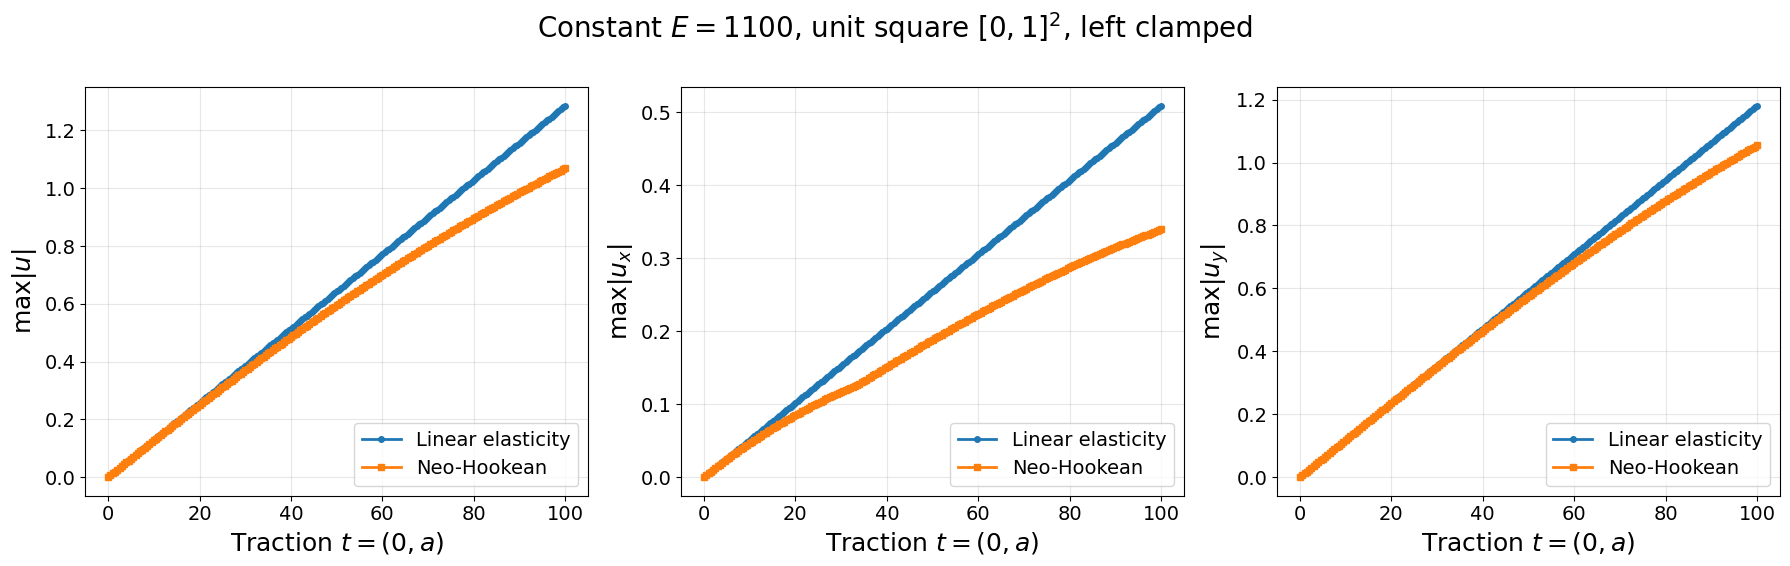

Saved /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/problems/hyperelasticity/compare_with_linear_elasticity/Results/displacement_extrema_vs_traction_E_1100_nu_0.45.png


In [5]:
fs_label = 18
fs_tick = 14
fs_suptitle = 20
fs_legend = 14

fig, axs = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True)

panels = [
    (r"$\max |u|$", max_u_lin, max_u_neo),
    (r"$\max |u_x|$", max_ux_lin, max_ux_neo),
    (r"$\max |u_y|$", max_uy_lin, max_uy_neo),
]

for ax, (ylabel, lin_vals, neo_vals) in zip(axs, panels):
    ax.plot(traction_values, lin_vals, "o-", label="Linear elasticity", linewidth=2, markersize=4)
    ax.plot(
        traction_values[neo_converged],
        neo_vals[neo_converged],
        "s-",
        label="Hyperelasticity",
        linewidth=2,
        markersize=4,
    )
    if not np.all(neo_converged):
        failed = traction_values[~neo_converged]
        ax.plot(failed, np.zeros_like(failed), "x", color="C3", markersize=8, label="Neo (no conv.)")
    ax.set_xlabel(r"Traction $t = (0, a)$", fontsize=fs_label)
    ax.set_ylabel(ylabel, fontsize=fs_label)
    ax.tick_params(axis="both", labelsize=fs_tick)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=fs_legend)

fig.suptitle(
    rf"Constant $E={E:.0f}$, unit square $[0,1]^2$, left clamped",
    fontsize=fs_suptitle,
    y=1.02,
)
fig.tight_layout()
fig.subplots_adjust(top=0.88)

results_dir = os.path.join(NOTEBOOK_DIR, "Results")
os.makedirs(results_dir, exist_ok=True)
save_path = os.path.join(results_dir, f"displacement_extrema_vs_traction_E_{E:.0f}_nu_{nu:.2f}.png")
plt.savefig(save_path, bbox_inches="tight", dpi=150)
plt.show()
print("Saved", save_path)


In [4]:
for name, lin_vals, neo_vals in [
    ("|u|", max_u_lin, max_u_neo),
    ("|ux|", max_ux_lin, max_ux_neo),
    ("|uy|", max_uy_lin, max_uy_neo),
]:
    print(f"\nNeo / linear ratio for max {name}:")
    for a in [0, 10, 20, 30, 40, 50]:
        i = int(a)
        if i >= len(traction_values):
            continue
        if neo_converged[i] and lin_vals[i] > 0:
            print(f"  a={a:2d}: ratio={neo_vals[i] / lin_vals[i]:.4f}")
        elif neo_converged[i]:
            print(f"  a={a:2d}: 0 (both zero)")
        else:
            print(f"  a={a:2d}: Hyperelasticity did not converge")



Neo / linear ratio for max |u|:
  a= 0: 0 (both zero)
  a=10: ratio=0.9934
  a=20: ratio=0.9868
  a=30: ratio=0.9801
  a=40: ratio=0.9731
  a=50: ratio=0.9660

Neo / linear ratio for max |ux|:
  a= 0: 0 (both zero)
  a=10: ratio=0.9572
  a=20: ratio=0.9154
  a=30: ratio=0.8746
  a=40: ratio=0.8357
  a=50: ratio=0.7993

Neo / linear ratio for max |uy|:
  a= 0: 0 (both zero)
  a=10: ratio=1.0000
  a=20: ratio=0.9995
  a=30: ratio=0.9984
  a=40: ratio=0.9967
  a=50: ratio=0.9944
